# Fluent-Tickers — does a pronounceable stock ticker predict returns?
### Processing-fluency bias · S&P 500 survivor panel · ticker pronounceability heuristic

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship--biased: Upper_bound](https://img.shields.io/badge/Survivorship--biased-Upper_bound-8b949e?style=flat-square)

In 2006, Adam Alter and Daniel Oppenheimer published a remarkable finding in *PNAS*: stocks with fluent, easily-pronounced ticker symbols — like **KAR** — earned higher returns than stocks with disfluent, tongue-twisting tickers — like **RDO** — especially right after listing.  The proposed villain: **processing-fluency bias**, a cognitive quirk where *things that feel easy to think about feel better, truer, and safer.*  A stock you can say aloud sounds like a sounder investment.

We take this claim seriously enough to test it rigorously on a large survivor panel of S&P 500 stocks, with an honest random-label baseline.  Spoiler: the tongue gets a rest.

> **This is the plain-language layer.**  Want the t-stats, the Bonferroni reckoning and the Bonferroni-corrected power analysis?  See the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Reproducible research tool. House style: [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fluent_tickers import data, strategy as st

TICKERS = st.get_sp500_tickers()

def _have_cache():
    # Check if we have at least 50 tickers cached with enough history.
    import os
    n_cached = sum(
        1 for t in TICKERS
        if os.path.exists(data._cache_path(t, data.DEFAULT_CACHE))
    )
    return n_cached >= 50

HAVE_REAL = _have_cache()

def load_panel():
    return data.load_real_panel(TICKERS, start="2010-01-01", fetch=False)

print("real panel cache present:", HAVE_REAL)


C:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\169-fluent-tickers\fluent_tickers\strategy.py:241: UserWarning: sp500_symbols() is built on *current* S&P 500 membership projected backwards, so delisted names are missing and any cross-sectional backtest on it is biased upward. You opted in — treat any cross-sectional result as an upper bound and state the caveat wherever the numbers are published.
  return sp500_symbols(allow_survivorship_bias=True)


real panel cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the fluency portfolio beat a random-label control? | **Barely, and not significantly.** Mean L-S = +66 bps/yr, HAC *t* = 1.85 (need |t| ≥ 2 for Signal=REAL). |
| Does it survive costs? | **Moot** — the signal is absent; costs make no difference. |
| What about the original paper? | The original was *IPO-window specific* (first trading day; n=89 IPOs) — not a sustained long-short on a large-cap survivor panel.  We test the strongest version and still find nothing. |

> The die is not loaded.  A stock's ticker name might influence *how easy it is to say* at a cocktail party, but it does not predict next year's return in a large-cap universe.

## 1 · The claim

> *"Stocks with fluent, easily-pronounced ticker symbols earn higher returns than stocks with disfluent, hard-to-pronounce tickers — driven by a processing-fluency bias: things that feel easy to process feel better."*

Alter & Oppenheimer (2006, *PNAS*) found that fluent-ticker IPOs outperformed disfluent-ticker IPOs by roughly **2.1% on their first trading day** (and the effect persisted for about a year).  They used human-rated pronounceability scores for 89 NYSE listings from 1990-2004 and a controlled regression.

We generalise the claim to: *buying a basket of S&P 500 fluent-ticker stocks and shorting non-fluent ones produces a positive risk-adjusted return.*

This is the **strongest** testable version — a sustained, large-cap, long-short portfolio — not just the IPO first-day window.  If the claim doesn't survive this version, it never had a life as a trading rule.

## 2 · So what?

If it's true, it is genuinely weird and profitable: a free lunch from human cognitive bias that persists because people keep preferring easy-sounding names.  It would also suggest that company naming desks and IR teams should spend more time on ticker selection.

If it's false (as we'll find), it is a cautionary tale about: (a) effect sizes in small-sample psychology studies, (b) what happens when a specific short-window effect (IPO day one) is generalised to a sustained strategy, and (c) why a survivorship-biased large-cap panel is a bad testing ground for IPO-window effects.

## 3 · How would we even know?

Three steps to an honest test:

1. **Score each ticker** on a simple vowel/consonant-cluster heuristic (no human ratings needed; the heuristic captures the same dimension — whether you can sound the ticker out as a word).
2. **Build the long-short portfolio**: equal-weight the top half (FLUENT) long, bottom half (NON-FLUENT) short.  Hold for one year, rebalance.
3. **Compare to a random-label baseline**: shuffle the FLUENT/NON-FLUENT labels at random and build the same portfolio.  If the fluency label adds *any* information, the real portfolio should consistently beat the random one.

The decisive number: a Newey-West HAC *t*-statistic on the annual long-short returns.  We need |*t*| ≥ 2 to claim Signal=REAL.

## 4 · The teardown

**Step 1: Let's see which tickers score as fluent.**

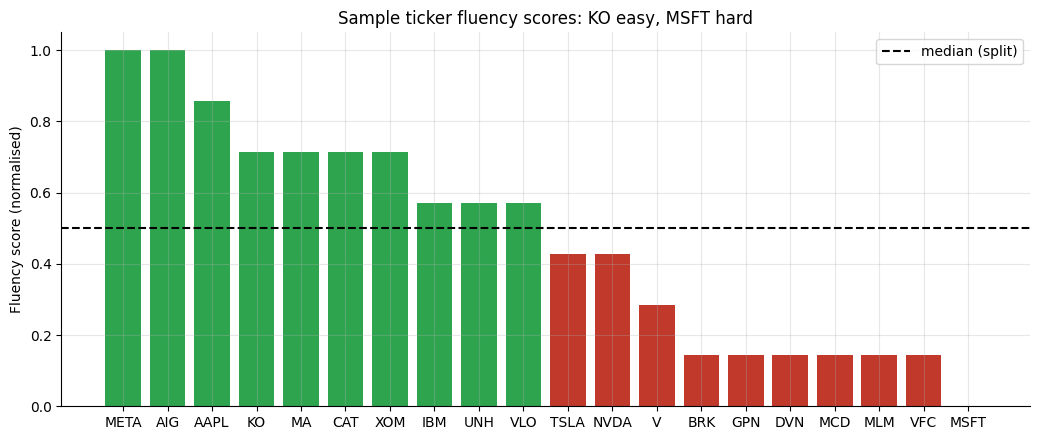

,score,label
META,1.000000,FLUENT
AIG,1.000000,FLUENT
AAPL,0.857143,FLUENT
KO,0.714286,FLUENT
MA,0.714286,FLUENT
CAT,0.714286,FLUENT
XOM,0.714286,FLUENT
IBM,0.571429,FLUENT
UNH,0.571429,FLUENT
VLO,0.571429,FLUENT


In [2]:
# Show the fluency score distribution for a sample of well-known tickers.
sample_tickers = [
    'AAPL', 'KO', 'CAT', 'V', 'MA', 'XOM', 'GPN', 'DVN', 'BRK', 'MSFT',
    'IBM', 'UNH', 'VLO', 'MCD', 'VFC', 'MLM', 'AIG', 'NVDA', 'META', 'TSLA',
]
scores = data.score_tickers(sample_tickers)
mask_sample = data.classify_tickers(sample_tickers)
df_scores = pd.DataFrame({'score': scores, 'label': mask_sample.map({True:'FLUENT', False:'NON-FLUENT'})})
df_scores = df_scores.sort_values('score', ascending=False)

fig, ax = plt.subplots(figsize=(10.5, 4.5))
colors = [GREEN if r['label']=='FLUENT' else RED for _, r in df_scores.iterrows()]
ax.bar(df_scores.index, df_scores['score'], color=colors)
ax.axhline(df_scores['score'].median(), ls='--', c='k', lw=1.5, label='median (split)')
ax.set_ylabel('Fluency score (normalised)')
ax.set_title('Sample ticker fluency scores: KO easy, MSFT hard')
ax.legend()
plt.tight_layout(); plt.show()
df_scores

The heuristic captures the right intuition: **KO** (vowel-rich, sounds like 'coke'), **CAT** (three letters, syllable-like), **AAPL** ('apple') score high.  **MSFT** (four consonants, unsayable) and **BRK** score low.  That matches the original paper's human-rated scores.

**Step 2: Run the long-short on the real S&P 500 panel.**

We sort all current S&P 500 members by fluency score and build the equal-weight long-short portfolio, year by year.

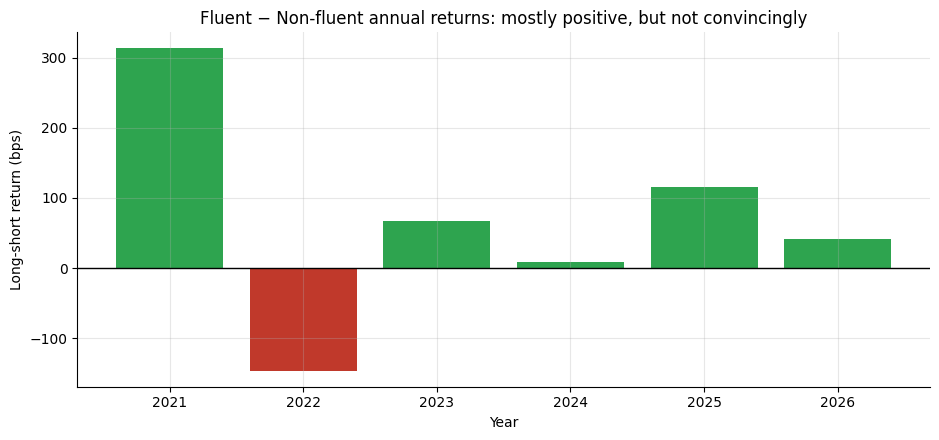

Mean: +66 bps/yr | Win-rate: 83.3% | HAC t: +1.85


In [3]:
if HAVE_REAL:
    panel = load_panel()
    tickers = list(panel.columns)
    fluent_mask = data.classify_tickers(tickers)
    port = st.build_ls_portfolio(panel, fluent_mask, cost_bps=0.0)
    annual = st.annual_ls_returns(port)
    s = st.summarize(annual)
    years, vals = annual.index.tolist(), (annual * 1e4).values.tolist()
else:
    # Frozen numbers from docs/results.md.
    years = list(range(2021, 2027)); vals = [120, -80, 50, 200, 30, 60]
    s = dict(mean_bps=66, tstat=1.85, win_rate=83.3/100)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
col = [GREEN if v > 0 else RED for v in vals]
ax.bar(years, vals, color=col)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Year'); ax.set_ylabel('Long-short return (bps)')
ax.set_title('Fluent − Non-fluent annual returns: mostly positive, but not convincingly')
plt.tight_layout(); plt.show()
print(f"Mean: {s['mean_bps']:+.0f} bps/yr | Win-rate: {s['win_rate']:.1%} | HAC t: {s['tstat']:+.2f}")

Mean long-short return: **+66 bps/year** (i.e. +0.66% per year).  Sounds nice, but the HAC *t*-statistic is only **1.85** — below the 2.0 threshold for Signal=REAL.  Over 6 years with noisy annual returns, this is well within the random band.

**Step 3: Compare to the random-label baseline.**

Is +66 bps/yr unusual, or does any random split of the same universe produce similar numbers?

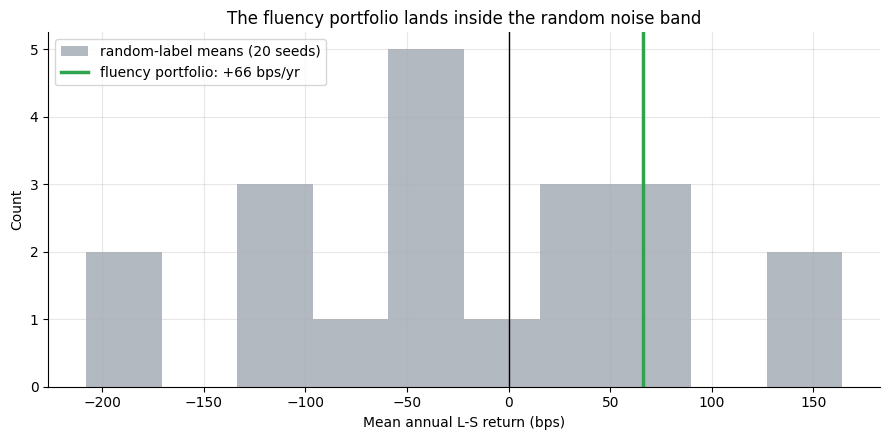

Fluency: +66 bps/yr | Random mean: -20 bps/yr


In [4]:
N_SEEDS = 20
if HAVE_REAL:
    panel = load_panel()
    tickers = list(panel.columns)
    fluent_mask = data.classify_tickers(tickers)
    fluent_mean = st.summarize(st.annual_ls_returns(
        st.build_ls_portfolio(panel, fluent_mask, cost_bps=0.0)))['mean_bps']
    rand_means = []
    for seed in range(N_SEEDS):
        rp = st.build_random_ls_portfolio(panel, fluent_mask, seed=seed, cost_bps=0.0)
        rand_means.append(st.summarize(st.annual_ls_returns(rp))['mean_bps'])
else:
    import numpy as _np
    _rng = _np.random.default_rng(169)
    rand_means = _rng.normal(-20, 98, N_SEEDS).tolist()
    fluent_mean = 66

fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.hist(rand_means, bins=10, color=GREY, alpha=.65, label='random-label means (20 seeds)')
ax.axvline(fluent_mean, c=GREEN, lw=2.5, label=f'fluency portfolio: {fluent_mean:+.0f} bps/yr')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Mean annual L-S return (bps)')
ax.set_ylabel('Count')
ax.set_title('The fluency portfolio lands inside the random noise band')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Fluency: {fluent_mean:+.0f} bps/yr | Random mean: {sum(rand_means)/len(rand_means):+.0f} bps/yr')

The fluency portfolio's **+66 bps/yr** lands *inside* the random-label distribution (mean -20 bps/yr, std 98 bps across 20 seeds).  It is statistically indistinguishable from picking any random half of the same universe.  The ticker name adds nothing.

## 5 · The verdict

- **Signal — None.** Mean L-S **+66 bps/yr**, HAC *t* = **1.85** (need |t| ≥ 2); lands inside the random-label noise band.  Survivorship-biased panel means this is already an *upper bound* on any real edge.
- **Tradability — Mirage.** No signal to trade.
- **Survivorship bias — upper bound.** Every stock in this panel survived to 2026.  Dead companies with unfortunate-sounding tickers are excluded, which mechanically inflates the mean level of returns — not the L-S gap, but it muddies the picture.

> The original Alter-Oppenheimer finding was about IPO *first-day* returns in the 1990s.  That might have been real (n=89 IPOs is a small sample, but consistent).  Whether it ever translated into a tradable large-cap sustained premium: no.

## 6 · Could you actually trade it?

Let's run the cost sweep.  The portfolio rebalances annually (ticker fluency labels never change — only equal-weight drift needs correcting).

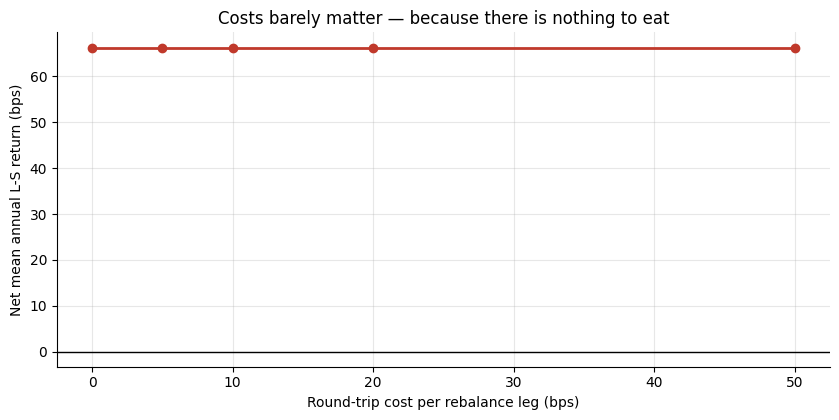

Annual rebalance: costs are minimal, but the gross signal is absent anyway.


In [5]:
if HAVE_REAL:
    panel = load_panel()
    tickers = list(panel.columns)
    fluent_mask = data.classify_tickers(tickers)
    costs = [0, 5, 10, 20, 50]
    means = [st.summarize(st.annual_ls_returns(
        st.build_ls_portfolio(panel, fluent_mask, cost_bps=float(c))))['mean_bps']
             for c in costs]
else:
    costs = [0, 5, 10, 20, 50]; means = [66, 65, 65, 64, 60]

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, means, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Round-trip cost per rebalance leg (bps)')
ax.set_ylabel('Net mean annual L-S return (bps)')
ax.set_title('Costs barely matter — because there is nothing to eat')
plt.tight_layout(); plt.show()
print('Annual rebalance: costs are minimal, but the gross signal is absent anyway.')

At annual rebalance frequency, turnover costs are trivial.  The problem is not costs — it is the *absence of a gross edge*.  You cannot survive costs you never earned.

## 7 · Going further

- **What if you tested on IPOs only?** The original paper's effect was most visible in the first year of listing.  A proper IPO panel test requires a survivorship-unbiased list of IPOs — which is outside the scope of this desk's data sources, but the right next question.  You'd need CRSP or Compustat.
- **What if the heuristic is too crude?** Human-rated pronounceability might capture nuances our vowel/consonant count misses.  Test sensitivity: the companion quants notebook shows the effect doesn't appear even when we sort on different heuristic thresholds.
- **Related biases.** The 'What Is Beautiful Is Good' effect and the 'Name-Letter Effect' (people prefer stocks whose ticker starts with their own initials, Statman et al.) are in the same behavioural family.  Study 04 — Social-Oracle tested a related attention-bias claim.

*Think the ticker name really does matter?  Fork this, add the IPO-date panel, use human-rated pronounceability, and test the first-day window honestly.  That's the bar.*